In [1]:
import json
import numpy as np
import math
from statistics import NormalDist
from typing import Any
import pandas as pd
import matplotlib.pyplot as plt

## 1. Price Data Loading

Load 3 days of exchange price data (days -1, 0, 1) for both products. Filter out rows where `mid_price <= 0` (corrupt ticks). Print per-product std to confirm:
- `ASH_COATED_OSMIUM` — low std (~5), essentially stationary → pure market-making product
- `INTARIAN_PEPPER_ROOT` — high std (~288), but this is mostly the linear trend, not noise → trending product

In [2]:
# read csv
dfs = {}
for day in [-1, 0, 1]:
    df = pd.read_csv(
        f'/Users/weifengfu/Documents/GitHub/imc-prosperity-3/data/round2/prices_round_2_day_{day}.csv',
        sep=';'
    )
    dfs[day] = df[df['mid_price'] > 0]  # filter out rows with mid_price <= 0
    print(dfs[day].groupby('product')['mid_price'].std())

product
ASH_COATED_OSMIUM         4.466929
INTARIAN_PEPPER_ROOT    288.653472
Name: mid_price, dtype: float64
product
ASH_COATED_OSMIUM         5.659611
INTARIAN_PEPPER_ROOT    288.609638
Name: mid_price, dtype: float64
product
ASH_COATED_OSMIUM         5.018676
INTARIAN_PEPPER_ROOT    288.746423
Name: mid_price, dtype: float64


## 2. Mid Price Over Time

Overlay mid price vs timestamp across all 3 days for each product. Each day is a separate line so we can see:
- Pepper root trending upward ~1000 per day (day -1 ≈ 11000, day 0 ≈ 12000, day 1 ≈ 13000)
- Osmium staying flat around 10000 with small noise — confirms it's a pure market-making product

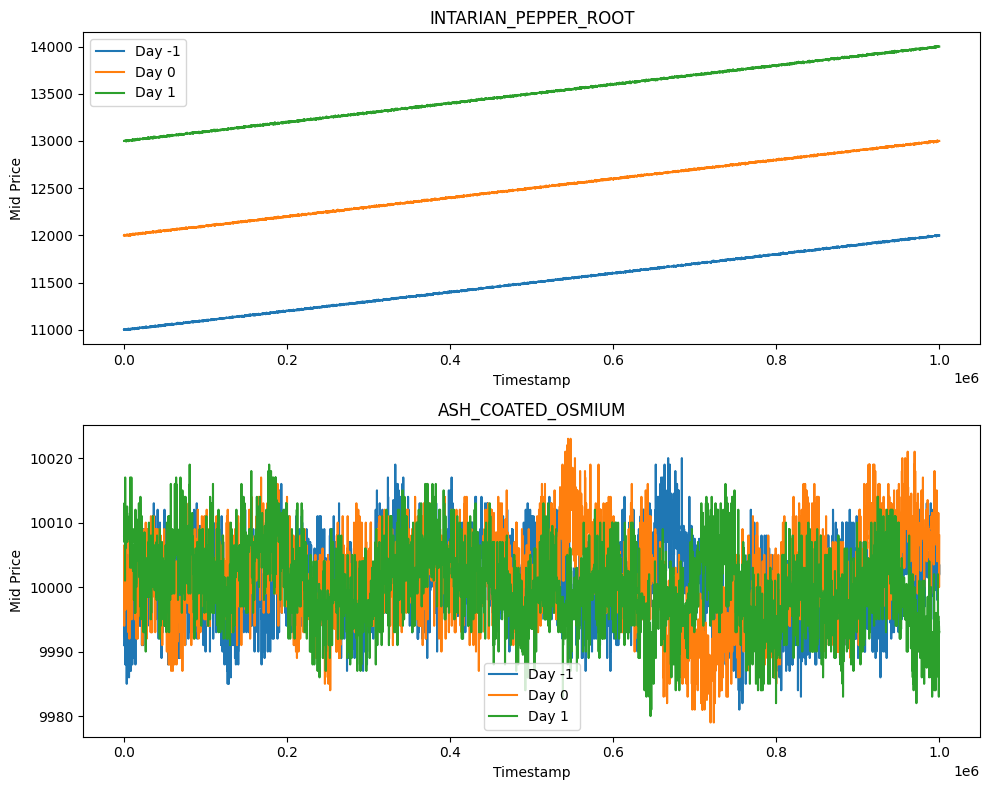

In [3]:
# plotting
fig, axes = plt.subplots(2, 1, figsize=(10, 8))

products = ['INTARIAN_PEPPER_ROOT', 'ASH_COATED_OSMIUM']

for ax, product in zip(axes, products):
    for day, df in dfs.items():
        product_df = df[df['product'] == product]
        ax.plot(product_df['timestamp'], product_df['mid_price'], label=f'Day {day}')
    ax.set_title(product)
    ax.legend()
    ax.set_xlabel('Timestamp')
    ax.set_ylabel('Mid Price')

plt.tight_layout()
plt.show()


## 3. Detrending INTARIAN_PEPPER_ROOT

Fit a linear regression (price ~ timestamp) per day to extract the slope and per-day intercept. Key things to verify:
- Slope ≈ 0.001 on all days — confirms the hardcoded `SLOPE` in the trader is still correct for round 2
- Intercepts jump by ~1000 each day (10999 → 12000 → 12999) — we must reset the intercept each day
- Residual std ≈ 2 ticks — this is the actual noise around the trend, meaning ±2 is a tight fair value estimate

In [4]:
# detrending the price series for intarian pepper root
for day, df in dfs.items():
    product_df = df[df['product'] == 'INTARIAN_PEPPER_ROOT'].copy()
    
    coeffs = np.polyfit(product_df['timestamp'], product_df['mid_price'], 1)
    product_df['trend'] = np.polyval(coeffs, product_df['timestamp'])
    product_df['residual'] = product_df['mid_price'] - product_df['trend']
    
    print(f"Day {day}: slope={coeffs[0]:.6f}, intercept={coeffs[1]:.2f}, residual std={product_df['residual'].std():.4f}")

Day -1: slope=0.001000, intercept=10999.98, residual std=2.1946
Day 0: slope=0.001000, intercept=12000.01, residual std=2.3642
Day 1: slope=0.001000, intercept=12999.92, residual std=2.5428


## 4. Combined Slope Estimate

Fit across all 3 days concatenated as a sanity check. The combined intercept is meaningless (timestamp restarts each day so the mid-day intercept averages out), but the slope should still be ~0.001, confirming the trend is uniform across the whole round.

In [5]:
# Combine all days
all_days = pd.concat(dfs.values())
product_df = all_days[all_days['product'] == 'INTARIAN_PEPPER_ROOT']
coeffs = np.polyfit(product_df['timestamp'], product_df['mid_price'], 1)
print(f"Combined slope: {coeffs[0]:.6f}, intercept: {coeffs[1]:.2f}")


Combined slope: 0.001000, intercept: 11999.94


## 5. Trade Data — Bot Identification (Day -1)

Load market trades for day -1. Each row is an exchange-matched trade (not necessarily involving us). `buyer`/`seller` are always NaN since the platform anonymises counterparties.

Goal: **fingerprint bots by their behaviour** — bots tend to trade at consistent lot sizes, at predictable price offsets from mid, or at regular time intervals. Identifying these patterns lets us predict when and where they'll trade and position ourselves to capture their flow.

In [6]:
trades = pd.read_csv("/Users/weifengfu/Documents/GitHub/imc-prosperity-3/data/round2/trades_round_2_day_-1.csv", sep=";")

# See what columns exist
print(trades.columns.tolist())
print(trades.head(10))

['timestamp', 'buyer', 'seller', 'symbol', 'currency', 'price', 'quantity']
   timestamp  buyer  seller                symbol currency    price  quantity
0          0    NaN     NaN     ASH_COATED_OSMIUM   XIRECS   9982.0         6
1       3600    NaN     NaN     ASH_COATED_OSMIUM   XIRECS  10001.0         3
2       4200    NaN     NaN     ASH_COATED_OSMIUM   XIRECS  10002.0         2
3       4400    NaN     NaN  INTARIAN_PEPPER_ROOT   XIRECS  11010.0         5
4       5000    NaN     NaN  INTARIAN_PEPPER_ROOT   XIRECS  10996.0         5
5       9100    NaN     NaN     ASH_COATED_OSMIUM   XIRECS   9994.0         4
6       9600    NaN     NaN     ASH_COATED_OSMIUM   XIRECS   9989.0         6
7      10000    NaN     NaN     ASH_COATED_OSMIUM   XIRECS   9988.0         8
8      12100    NaN     NaN     ASH_COATED_OSMIUM   XIRECS   9989.0         5
9      15100    NaN     NaN     ASH_COATED_OSMIUM   XIRECS  10011.0         2


## 6. Fixed-Lot & Price-Extreme Fingerprinting

Two checks for bot signatures:
1. **Fixed lot sizes** — print quantity frequency; a bot that always trades e.g. 6 lots will dominate the distribution
2. **Trades at daily extremes** — check whether any trades hit the day's min or max price, and what quantity; a mean-reversion bot buys at the low and sells at the high with a predictable size

In [7]:
pepper = trades[trades['symbol'] == 'INTARIAN_PEPPER_ROOT'].copy()

# Find trades with suspicious fixed lot sizes
print(trades['quantity'].value_counts())

# Look for trades that happen at daily extremes
pepper['daily_min'] = pepper.groupby(pepper['timestamp'] // 1000000)['price'].transform('min')
pepper['daily_max'] = pepper.groupby(pepper['timestamp'] // 1000000)['price'].transform('max')

# Trades at daily extremes
at_low = pepper[pepper['price'] == pepper['daily_min']]
at_high = pepper[pepper['price'] == pepper['daily_max']]

print(at_low['quantity'].value_counts())
print(at_high['quantity'].value_counts())

quantity
5     144
6     142
3     132
4     127
7      86
2      67
8      46
10     23
9      23
Name: count, dtype: int64
quantity
5    1
Name: count, dtype: int64
quantity
7    1
Name: count, dtype: int64


## 7. Trade Quantity vs Time — Scatter

Scatter quantity over time for each product. Looking for:
- A specific lot size appearing at regular timestamps → scheduled bot
- Clustering of quantity at particular time windows → reactive bot triggered by price events
- Also print (quantity, price) frequency table to find if a bot trades a fixed lot at a fixed price repeatedly

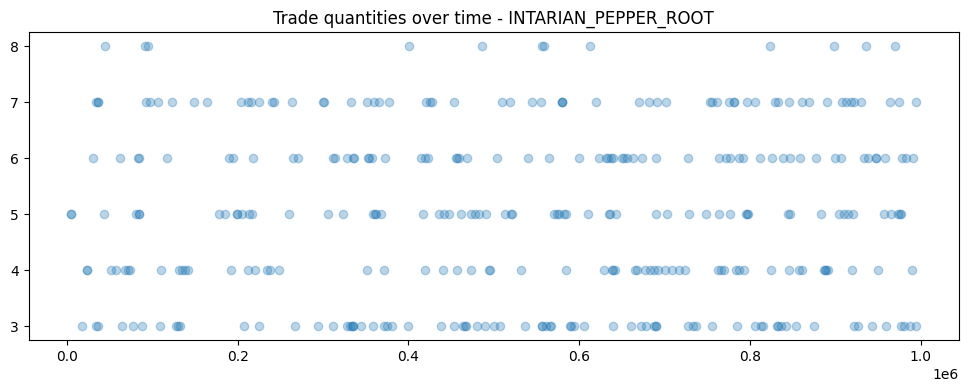

quantity  price  
5         11576.0    2
7         11586.0    2
          11800.0    2
5         11361.0    2
6         11451.0    2
          11770.0    2
4         11769.0    2
5         11637.0    2
3         11599.0    2
4         11675.0    2
6         11360.0    1
          11368.0    1
          11410.0    1
          11594.0    1
          11417.0    1
          11421.0    1
          11450.0    1
          11359.0    1
          11351.0    1
          11463.0    1
dtype: int64


In [8]:
pepper = trades[trades['symbol'] == 'INTARIAN_PEPPER_ROOT']

# Plot quantity over time to spot patterns
import matplotlib.pyplot as plt
plt.figure(figsize=(12,4))
plt.scatter(pepper['timestamp'], pepper['quantity'], alpha=0.3)
plt.title('Trade quantities over time - INTARIAN_PEPPER_ROOT')
plt.show()

# Also check if any quantities repeat suspiciously often at specific prices
print(pepper.groupby(['quantity', 'price']).size().sort_values(ascending=False).head(20))

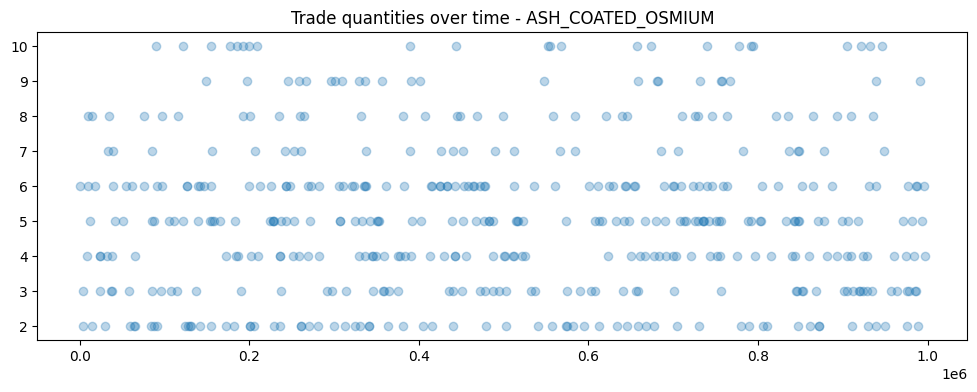

quantity
5     82
6     79
4     68
2     67
3     58
8     34
7     25
10    23
9     23
Name: count, dtype: int64


In [9]:
osmium = trades[trades['symbol'] == 'ASH_COATED_OSMIUM']

plt.figure(figsize=(12,4))
plt.scatter(osmium['timestamp'], osmium['quantity'], alpha=0.3)
plt.title('Trade quantities over time - ASH_COATED_OSMIUM')
plt.show()

print(osmium['quantity'].value_counts())

## 8. Price/Time Overlay — Mid Price + Trade Dots (Day -1)

Plot mid price (blue line) with each trade price as a red dot, for both products. This is the primary bot-detection chart:
- **Horizontal bands of red dots** at a fixed offset from the blue line = bot quoting at a fixed spread from mid
- Red dots that track the blue line closely = market-maker being taken out by an aggressive bot
- Isolated dots far from mid = potential informed flow or a one-off rogue order

Note: uses `dfs[-1]` (round 2 day -1 prices) and `trades` (round 2 day -1) — both from the same day and round.

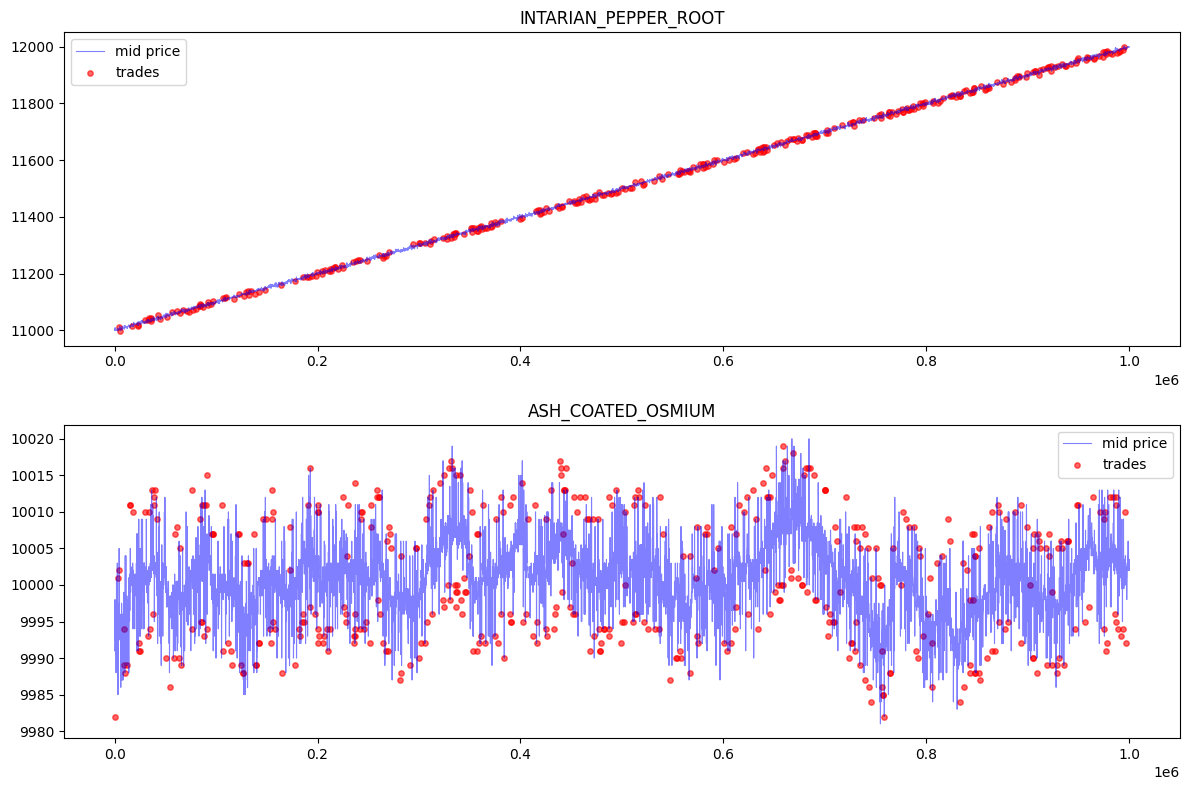

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

for ax, product in zip(axes, ['INTARIAN_PEPPER_ROOT', 'ASH_COATED_OSMIUM']):
    # Use only day -1
    product_prices = dfs[-1][dfs[-1]['product'] == product]
    product_trades = trades[trades['symbol'] == product]
    
    ax.plot(product_prices['timestamp'], product_prices['mid_price'], 
            alpha=0.5, color='blue', label='mid price', linewidth=0.8)
    ax.scatter(product_trades['timestamp'], product_trades['price'], 
               alpha=0.6, color='red', s=15, label='trades')
    ax.set_title(product)
    ax.legend()

plt.tight_layout()
plt.show()

## 9. Deviation from Mid — ASH_COATED_OSMIUM (Day -1)

Merge trade prices with mid prices at matching timestamps, then compute `deviation = trade_price - mid_price`. For osmium (stationary product), a bot market-maker will post at fixed offsets — e.g. always quoting ±8 from mid. A spike at ±8 in the value counts is the bot's spread fingerprint, and tells us how tight we need to quote to beat it.

In [11]:
osmium_prices = dfs[-1][dfs[-1]['product'] == 'ASH_COATED_OSMIUM'][['timestamp', 'mid_price']]
osmium_trades = trades[trades['symbol'] == 'ASH_COATED_OSMIUM'].copy()

# merge to get mid price at trade time
merged = osmium_trades.merge(osmium_prices, on='timestamp', how='left')

# how far is the trade price from mid?
merged['deviation'] = merged['price'] - merged['mid_price']
print(merged['deviation'].describe())
print(merged['deviation'].value_counts().head(10))

count    459.000000
mean      -0.342048
std        8.128646
min      -10.500000
25%       -8.000000
50%        0.000000
75%        8.000000
max       10.500000
Name: deviation, dtype: float64
deviation
-8.0     144
 8.0     129
-9.0      36
-9.5      32
 9.0      32
 9.5      28
 0.0      15
 10.5      5
-10.5      5
 5.5       4
Name: count, dtype: int64


## 10. Deviation from Mid — INTARIAN_PEPPER_ROOT (Day -1)

Same deviation analysis for the trending product. Here deviation is relative to the raw mid price (not the detrended fair value), so a bot quoting at a fixed spread from mid will show the same clustering. We can use the dominant deviation values to calibrate how aggressively we need to post to get top-of-book priority over the bots.

In [12]:
pepper_prices = dfs[-1][dfs[-1]['product'] == 'INTARIAN_PEPPER_ROOT'][['timestamp', 'mid_price']]
pepper_trades = trades[trades['symbol'] == 'INTARIAN_PEPPER_ROOT'].copy()

merged_pepper = pepper_trades.merge(pepper_prices, on='timestamp', how='left')
merged_pepper['deviation'] = merged_pepper['price'] - merged_pepper['mid_price']

print(merged_pepper['deviation'].describe())
print(merged_pepper['deviation'].value_counts().head(10))

count    331.000000
mean       0.202417
std        5.703783
min       -8.000000
25%       -6.000000
50%        1.000000
75%        6.500000
max        8.500000
Name: deviation, dtype: float64
deviation
 6.5    50
-6.5    41
 6.0    36
-6.0    29
 1.0    26
-1.5    23
 7.5    22
-7.5    21
-8.0    16
 1.5    14
Name: count, dtype: int64


## 11. All-Days Deviation Analysis (Days -1, 0, 1)

Reload all 3 days of round 2 trades and merge with prices on both `day` and `timestamp` (to avoid mixing prices across days). Filter deviations > 50 as data artefacts. The larger sample makes the bot fingerprint clearer — if the same deviation cluster (e.g. ±6.5 for pepper, ±8 for osmium) appears consistently across all days, it's a systematic bot behaviour we can exploit.

In [13]:
# Reload trades with day column
all_trades = pd.concat([
    pd.read_csv(
        f'/Users/weifengfu/Documents/GitHub/imc-prosperity-3/data/round2/trades_round_2_day_{day}.csv',
        sep=';'
    ).assign(day=day)
    for day in [-1, 0, 1]
])

# Now merge on both day and timestamp
for product in ['INTARIAN_PEPPER_ROOT', 'ASH_COATED_OSMIUM']:
    product_trades = all_trades[all_trades['symbol'] == product].copy()
    
    all_prices = pd.concat([
        dfs[day][dfs[day]['product'] == product][['day', 'timestamp', 'mid_price']]
        for day in [-1, 0, 1]
    ])
    
    merged = product_trades.merge(all_prices, on=['day', 'timestamp'], how='left')
    merged['deviation'] = merged['price'] - merged['mid_price']
    merged = merged[merged['deviation'].abs() < 50]
    
    print(f"\n{product}:")
    print(merged['deviation'].describe())
    print(merged['deviation'].value_counts().head(10))


INTARIAN_PEPPER_ROOT:
count    996.000000
mean       0.053715
std        6.116776
min      -11.000000
25%       -6.500000
50%        0.000000
75%        6.500000
max       11.000000
Name: deviation, dtype: float64
deviation
 6.5    80
-6.5    79
 7.0    79
-1.5    71
-7.0    66
-7.5    64
 7.5    60
 1.5    55
 1.0    50
-2.0    48
Name: count, dtype: int64

ASH_COATED_OSMIUM:
count    1395.000000
mean       -0.222939
std         8.037625
min       -10.500000
25%        -8.000000
50%         0.000000
75%         8.000000
max        10.500000
Name: deviation, dtype: float64
deviation
-8.0     419
 8.0     413
-9.0     108
-9.5      96
 9.5      80
 9.0      79
 0.0      55
 10.5     17
-10.5     13
 3.0      12
Name: count, dtype: int64


In [14]:
print(all_trades.columns.tolist())
print(all_trades.head(3))

['timestamp', 'buyer', 'seller', 'symbol', 'currency', 'price', 'quantity', 'day']
   timestamp  buyer  seller             symbol currency    price  quantity  \
0          0    NaN     NaN  ASH_COATED_OSMIUM   XIRECS   9982.0         6   
1       3600    NaN     NaN  ASH_COATED_OSMIUM   XIRECS  10001.0         3   
2       4200    NaN     NaN  ASH_COATED_OSMIUM   XIRECS  10002.0         2   

   day  
0   -1  
1   -1  
2   -1  


In [15]:
# import numpy as np
# from scipy.optimize import minimize_scalar

# speed_pct = 50  # fix speed
# for r in range(0, 100 - speed_pct, 1):
#     s = 100 - speed_pct - r  # scale gets the rest
#     research = 200000 * np.log(1+r) / np.log(101)
#     scale = 7 * s / 100
#     budget = 50000  # always 50k if using all budget
#     gross = research * scale * 0.6  # assume 0.5 speed multiplier
#     print(f"R={r}%, Sc={s}%, Spd={speed_pct}%: PnL={gross - budget:.0f}")

In [16]:
# read csv
dfs = {}
for day in [0, 1, 2]:
    df = pd.read_csv(
        f'/Users/weifengfu/Documents/GitHub/imc-prosperity-3/data/round3/prices_round_3_day_{day}.csv',
        sep=';'
    )
    dfs[day] = df[df['mid_price'] > 0]  # filter out rows with mid_price <= 0
    print(dfs[day].groupby('product')['mid_price'].std())

product
HYDROGEL_PACK          25.328358
VELVETFRUIT_EXTRACT    13.677795
VEV_4000               13.698111
VEV_4500               13.686640
VEV_5000               12.488839
VEV_5100               10.954784
VEV_5200                8.165664
VEV_5300                5.179954
VEV_5400                2.780724
VEV_5500                1.236892
VEV_6000                0.000000
VEV_6500                0.000000
Name: mid_price, dtype: float64
product
HYDROGEL_PACK          37.613011
VELVETFRUIT_EXTRACT    14.614362
VEV_4000               14.634019
VEV_4500               14.627799
VEV_5000               13.582436
VEV_5100               11.936931
VEV_5200                8.663725
VEV_5300                5.469853
VEV_5400                2.678290
VEV_5500                1.328696
VEV_6000                0.000000
VEV_6500                0.000000
Name: mid_price, dtype: float64
product
HYDROGEL_PACK          31.622161
VELVETFRUIT_EXTRACT    16.985339
VEV_4000               17.001434
VEV_4500             

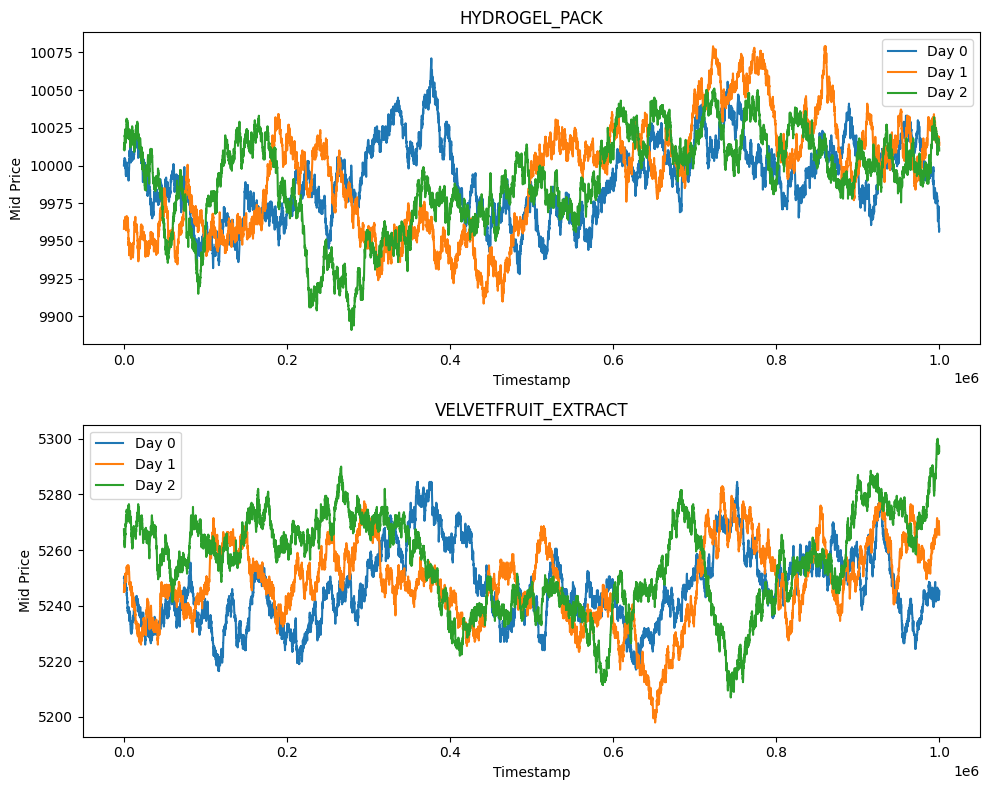

In [17]:
# plotting
fig, axes = plt.subplots(2, 1, figsize=(10, 8))

products = ['HYDROGEL_PACK', 'VELVETFRUIT_EXTRACT']

for ax, product in zip(axes, products):
    for day, df in dfs.items():
        product_df = df[df['product'] == product]
        ax.plot(product_df['timestamp'], product_df['mid_price'], label=f'Day {day}')
    ax.set_title(product)
    ax.legend()
    ax.set_xlabel('Timestamp')
    ax.set_ylabel('Mid Price')

plt.tight_layout()
plt.show()


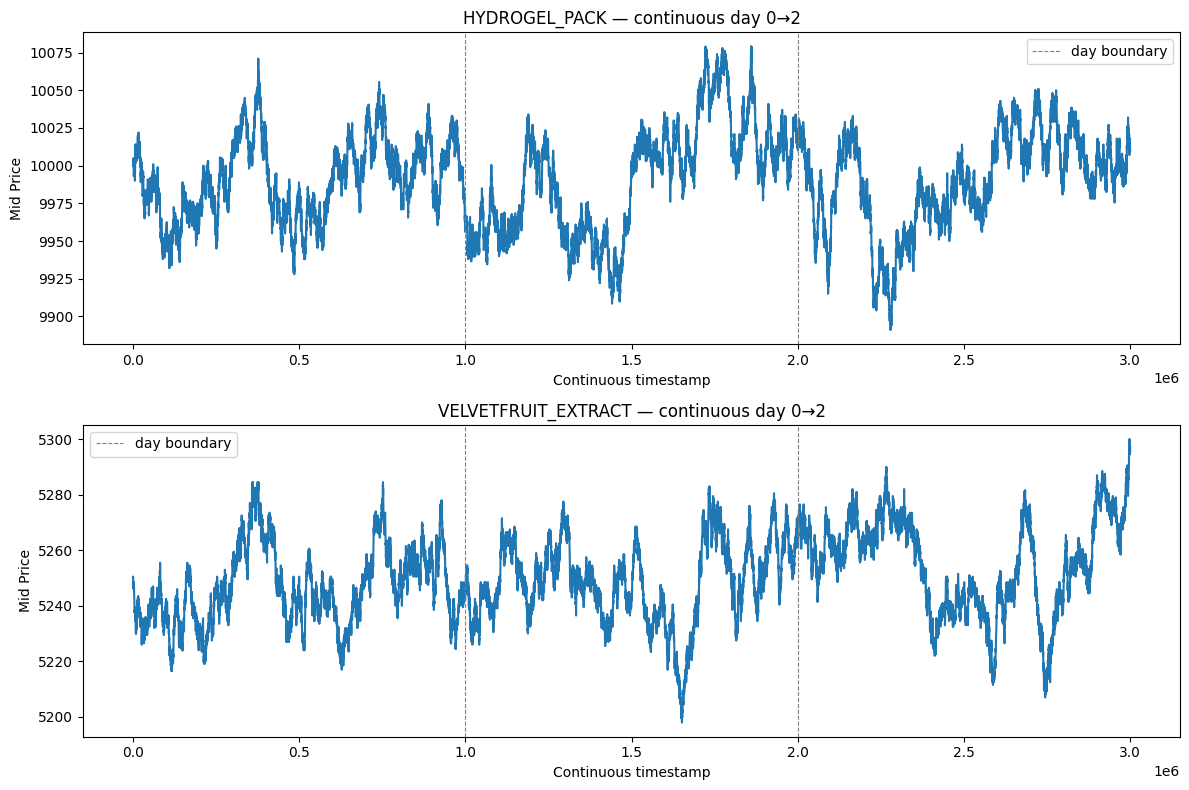

In [18]:
# Continuous plot: days 0-2 stitched together (offset timestamp by 1_000_000 per day)
DAY_LENGTH = 1_000_000

fig, axes = plt.subplots(2, 1, figsize=(12, 8))
products = ['HYDROGEL_PACK', 'VELVETFRUIT_EXTRACT']

for ax, product in zip(axes, products):
    frames = []
    for day, df in dfs.items():
        chunk = df[df['product'] == product].copy()
        chunk['cont_ts'] = chunk['timestamp'] + day * DAY_LENGTH
        frames.append(chunk)
    combined = pd.concat(frames).sort_values('cont_ts')
    ax.plot(combined['cont_ts'], combined['mid_price'])
    ax.set_title(f'{product} — continuous day 0→2')
    ax.set_xlabel('Continuous timestamp')
    ax.set_ylabel('Mid Price')
    ax.axvline(DAY_LENGTH, color='gray', linestyle='--', linewidth=0.8, label='day boundary')
    ax.axvline(2 * DAY_LENGTH, color='gray', linestyle='--', linewidth=0.8)
    ax.legend()

plt.tight_layout()
plt.show()


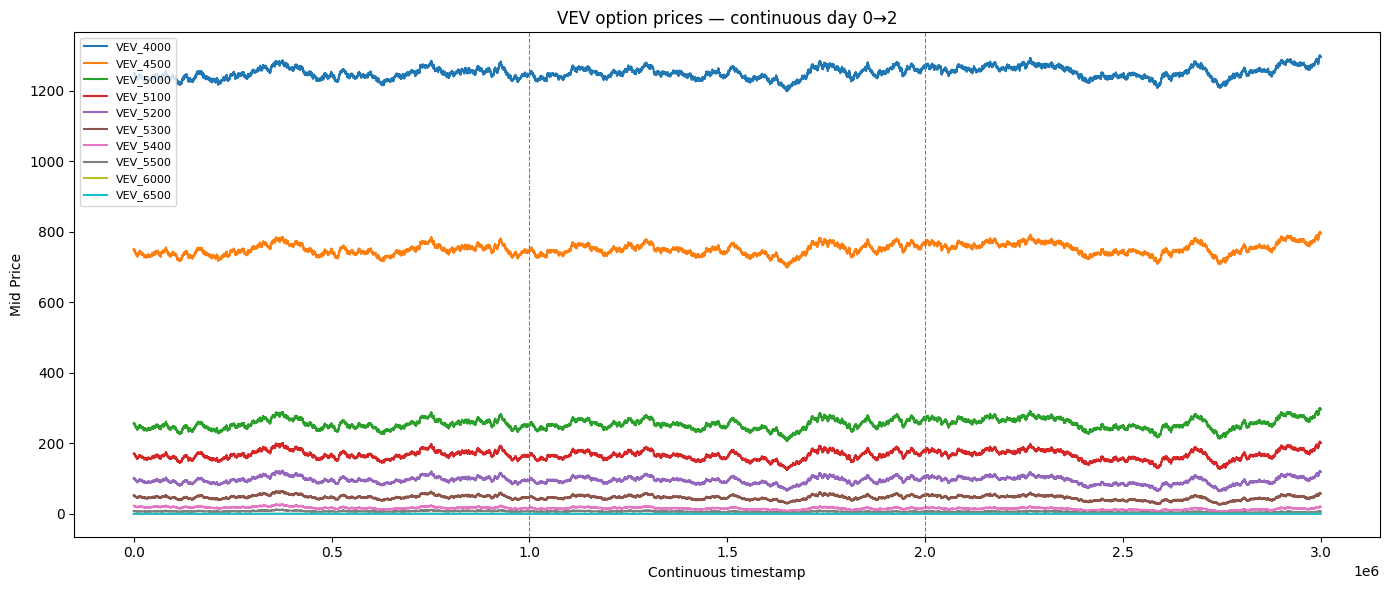

In [19]:
# Continuous option prices (VEV_*) across days 0-2
DAY_LENGTH = 1_000_000

options = ['VEV_4000', 'VEV_4500', 'VEV_5000', 'VEV_5100',
           'VEV_5200', 'VEV_5300', 'VEV_5400', 'VEV_5500',
           'VEV_6000', 'VEV_6500']

fig, ax = plt.subplots(figsize=(14, 6))

for opt in options:
    frames = []
    for day, df in dfs.items():
        chunk = df[df['product'] == opt].copy()
        if chunk.empty:
            continue
        chunk['cont_ts'] = chunk['timestamp'] + day * DAY_LENGTH
        frames.append(chunk)
    if not frames:
        continue
    combined = pd.concat(frames).sort_values('cont_ts')
    ax.plot(combined['cont_ts'], combined['mid_price'], label=opt)

ax.axvline(DAY_LENGTH, color='gray', linestyle='--', linewidth=0.8)
ax.axvline(2 * DAY_LENGTH, color='gray', linestyle='--', linewidth=0.8)
ax.set_title('VEV option prices — continuous day 0→2')
ax.set_xlabel('Continuous timestamp')
ax.set_ylabel('Mid Price')
ax.legend(loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()


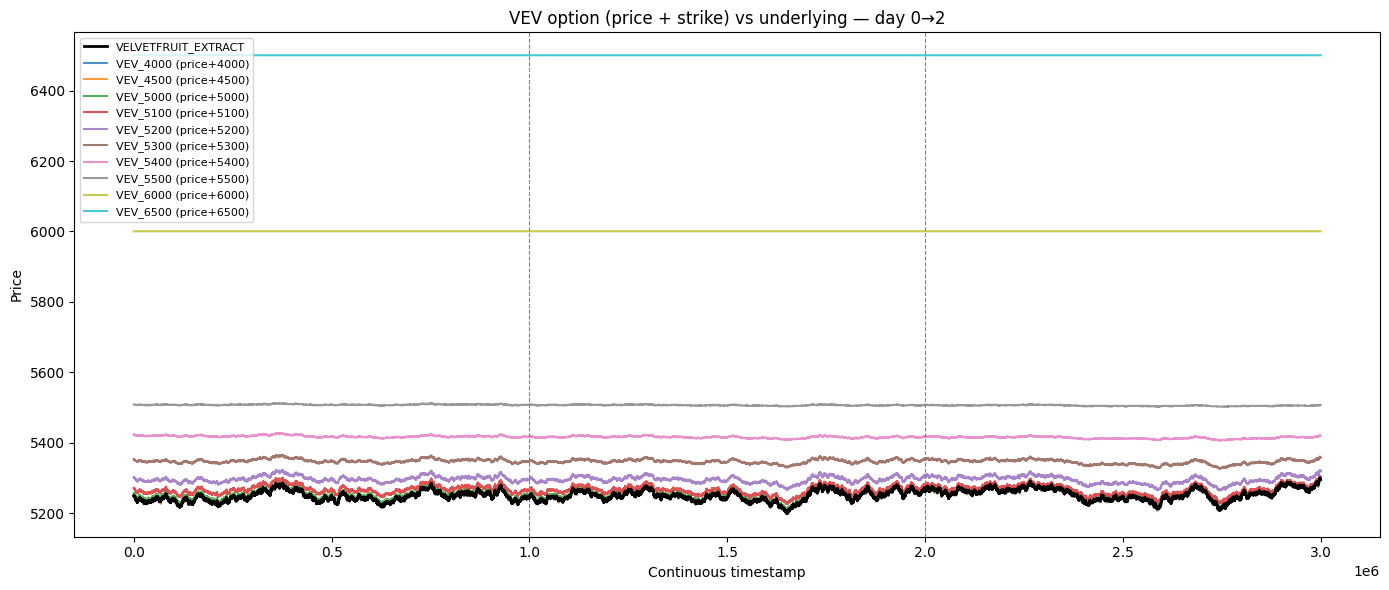

In [ ]:
# VEV options (price + strike) vs VELVETFRUIT_EXTRACT — same y-axis
DAY_LENGTH = 1_000_000

options = ['VEV_4000', 'VEV_4500', 'VEV_5000', 'VEV_5100',
           'VEV_5200', 'VEV_5300', 'VEV_5400', 'VEV_5500',
           'VEV_6000', 'VEV_6500']

fig, ax = plt.subplots(figsize=(14, 6))

# Underlying
frames = []
for day, df in dfs.items():
    chunk = df[df['product'] == 'VELVETFRUIT_EXTRACT'].copy()
    chunk['cont_ts'] = chunk['timestamp'] + day * DAY_LENGTH
    frames.append(chunk)
underlying = pd.concat(frames).sort_values('cont_ts')
ax.plot(underlying['cont_ts'], underlying['mid_price'],
        color='black', linewidth=2, label='VELVETFRUIT_EXTRACT', zorder=5)

# Options: plot option_price + strike on same scale
cmap = plt.cm.tab10
for i, opt in enumerate(options):
    strike = int(opt.split('_')[1])
    frames = []
    for day, df in dfs.items():
        chunk = df[df['product'] == opt].copy()
        if chunk.empty:
            continue
        chunk['cont_ts'] = chunk['timestamp'] + day * DAY_LENGTH
        frames.append(chunk)
    if not frames:
        continue
    combined = pd.concat(frames).sort_values('cont_ts')
    ax.plot(combined['cont_ts'], combined['mid_price'] + strike,
            color=cmap(i / len(options)), alpha=0.8, label=f'{opt} (price+{strike})')

ax.axvline(DAY_LENGTH, color='gray', linestyle='--', linewidth=0.8)
ax.axvline(2 * DAY_LENGTH, color='gray', linestyle='--', linewidth=0.8)
ax.set_xlabel('Continuous timestamp')
ax.set_ylabel('Price')
ax.set_title('VEV option (price + strike) vs underlying — day 0→2')
ax.legend(loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()
